# Keyboard Tracking

In [31]:
import os
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display

# Blender Export

### Exporting labels

```python
export_coordinates.py
```

### Preview Labels

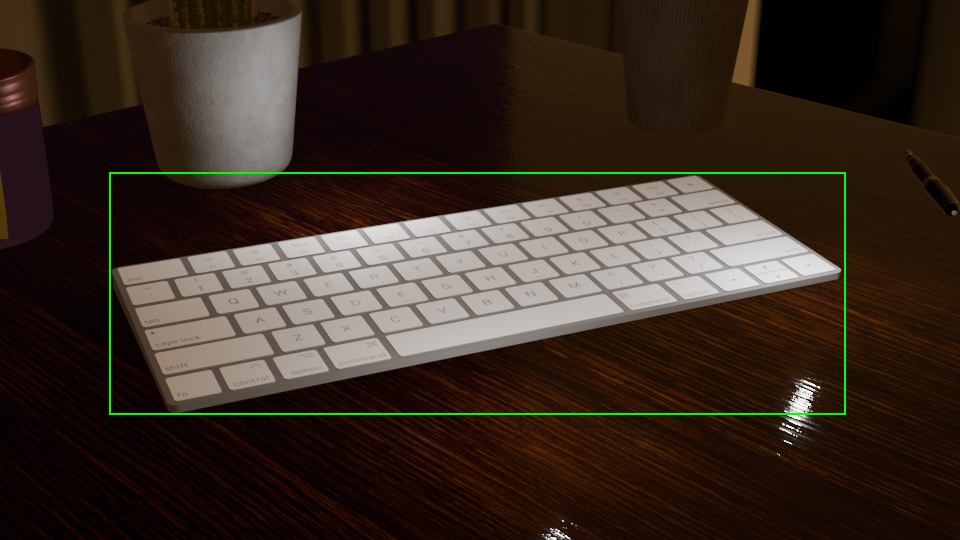

In [35]:
data_dir = os.path.abspath('../data/keyboard_tracking')

scene_name = 'Scene-1'

# Path to your CSV file
CSV_FILE = os.path.join(data_dir, f'labels_bbox/{scene_name}.csv')

# Folder where your rendered frames are located
# e.g., "C:/path/to/my_rendered_images"
IMAGE_FOLDER = os.path.join(data_dir, f'raw/{scene_name}')

def preview_blender_export(csv_file, image_folder, frame_number=0):
    """
    Reads the 2D coordinates from a CSV file, opens the corresponding
    rendered images, draws markers for each point, and saves new images
    to output_folder.
    """

    # Use DictReader so we can access columns by name
    keypoints_df = pd.read_csv(csv_file)

    # get row where Frame is equal to frame_number
    row = keypoints_df[keypoints_df['Frame'] == frame_number].iloc[0]
    
    # Build the image file name (e.g., frame_0001.png)
    # Adjust to match your own naming convention:
    image_filename = f"{scene_name}-{frame_number:04d}.png"
    image_path = os.path.join(image_folder, image_filename)

    # Try to open the image
    if not os.path.isfile(image_path):
        print(f"Warning: Image not found at {image_path}")
        return

    # Load image using Pillow
    with Image.open(image_path) as im:
        # get image size
        width, height = im.size

        draw = ImageDraw.Draw(im)

        # draw rectangle
        draw.rectangle([(int(row['min_x']) - 1, int(row['min_y']) - 1),
                        (int(row['max_x']) - 1, int(row['max_y']) - 1)],
                        outline=(0, 255, 0), width=2)

        # Show the image with the drawn points
        display(im)

preview_blender_export(CSV_FILE, IMAGE_FOLDER, frame_number=0)

In [33]:
import torch

USE_CPU = True

device = torch.device(
    "cuda:0" if torch.cuda.is_available() and not USE_CPU else
    "mps" if torch.backends.mps.is_available() and not USE_CPU else
    "cpu"
)
print('You are using the following device: ', device)

You are using the following device:  cpu


# Dataset

In [ ]:
import sys
sys.path.append(os.path.abspath('..'))

from models.keyboard_tracking.dataset import KeyboardTrackingDataset

data_dir = os.path.abspath('../data/keyboard_tracking')
labels_dir = os.path.join(data_dir, 'labels_bbox')
images_dir = os.path.join(data_dir, 'raw')

dataset = None # TODO: Load the dataset

train_size = int(len(dataset) * 0.7)
val_size = int(len(dataset) * 0.2)
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

### Preview Dataset

In [ ]:
import matplotlib.pyplot as plt

def preview_gt_keypoints(dataset, predicted_rectangle=None, idx=0):
    image, rectangle = dataset[idx]

    image = image.cpu().numpy().transpose(1, 2, 0)
    rectangle = rectangle.cpu().numpy()

    fig, ax = plt.subplots()
    ax.imshow(image, cmap='gray')
    rectangle = rectangle.reshape(-1, 2) - 1
    ax.add_patch(plt.Rectangle(
        (rectangle[0][0], rectangle[0][1]),
        rectangle[1][0] - rectangle[0][0],
        rectangle[1][1] - rectangle[0][1],
        linewidth=2,
        edgecolor='g',
        facecolor='none'
    ))
    if predicted_rectangle is not None:
        predicted_rectangle = predicted_rectangle.cpu().numpy()
        predicted_rectangle = predicted_rectangle.reshape(-1, 2) - 1
        ax.add_patch(plt.Rectangle(
            (predicted_rectangle[0][0], predicted_rectangle[0][1]),
            predicted_rectangle[1][0] - predicted_rectangle[0][0],
            predicted_rectangle[1][1] - predicted_rectangle[0][1],
            linewidth=2,
            edgecolor='r',
            facecolor='none'
        ))
    plt.show()

preview_gt_keypoints(train_dataset, idx=5)

# Training

In [7]:
hparams = {
    'device': device,
    'num_classes': 8,
    'num_workers': 8,
    'batch_size': 64,
    'learning_rate': 0.001,
    'weight_decay': 0.0001,
    'max_epochs': 40,
}